# Эксперименты с моделями СР2

Минимум 4–5 моделей + ансамбли, перебор гиперпараметров, обоснование финальной модели,
эксперименты с уменьшением размерности.

## Действия
1. Загрузка очищенного датасета из `02_baseline` (тот же `vacancies_clean.parquet`, тот же `SEED`)
2. Воспроизводимый сплит train/val/test стратификация по бинам log1p(salary)
3. Препроцессинг через `ColumnTransformer` числовые - `StandardScaler`, категориальные - `OneHotEncoder`, текст (название вакансии) - `TfidfVectorizer`
4. Обёртка `TransformedTargetRegressor` — учим модель на `log1p(y)`, метрики считаем в рублях
5. Эксперименты
   - baseline `Ridge` (для сверки с 02_baseline)
   - RandomForest + RandomizedSearchCV
   - SVM (`LinearSVR`) + GridSearchCV
   - CatBoost + RandomizedSearchCV
   - эксперимент с уменьшением размерности (TruncatedSVD)
6. Сводная таблица экспериментов на val
7. Финальная модель... оценка на test, сохранение в папку

## Главная метрика
`MAE` в рублях — основная. Дополнительно `RMSE` и `R²` для сравнения.
Все метрики считаются после `expm1` (возврат из log-пространства)

## 1. Импорты и настройки

In [1]:
from __future__ import annotations

import json
import time
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import loguniform, randint
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, RandomizedSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVR

from catboost import CatBoostRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORT_IMG = PROJECT_ROOT / "report" / "images"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORT_IMG.mkdir(parents=True, exist_ok=True)

TARGET = "salary_mid_rub"
DATA_PATH = DATA_PROCESSED / "vacancies_clean.parquet"
assert DATA_PATH.exists(), (
    f"Не найден {DATA_PATH}. Сначала пройти 01_eda.ipynb — он сохраняет vacancies_clean.parquet"
)

## 2. Загрузка данных и сплит

Воспроизводим тот же сплит, что и в 01_eda - 02_baseline. Стратификация по бинам `log1p(salary)`,
чтобы хвосты распределения попали во все три выборки

In [2]:
df = pd.read_parquet(DATA_PATH)

In [3]:
TARGET = "salary_mid_rub"

print("Статистика таргета")
print(df[TARGET].describe())

Статистика таргета
count    1.553900e+04
mean     1.031796e+05
std      6.607651e+04
min      1.000000e+04
25%      6.307500e+04
50%      8.700000e+04
75%      1.250000e+05
max      2.600000e+06
Name: salary_mid_rub, dtype: float64


In [4]:
print("Исключаем из фичей", [TARGET])
feature_cols = [c for c in df.columns if c not in [TARGET]]
print(f"Итого фичей {len(feature_cols)}")

Исключаем из фичей ['salary_mid_rub']
Итого фичей 15


In [5]:
salary_bins = pd.qcut(np.log1p(df[TARGET]), q=10, labels=False, duplicates="drop")

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    random_state=SEED,
    stratify=salary_bins,
)
temp_bins = salary_bins.loc[temp_df.index]

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_bins,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train = np.log1p(train_df[TARGET].values)
y_val = np.log1p(val_df[TARGET].values)
y_test = np.log1p(test_df[TARGET].values)

print(f"train {len(train_df):>7,}  ({len(train_df) / len(df):.1%})")
print(f"val {len(val_df):>7,}  ({len(val_df) / len(df):.1%})")
print(f"test {len(test_df):>7,}  ({len(test_df) / len(df):.1%})")

train  10,877  (70.0%)
val   2,331  (15.0%)
test   2,331  (15.0%)


## 3. Группировка фичей

Группы те же, что зафиксировали в EDA. Заодно отсекаем колонки с очевидным data leakage
(`salary_from_rub`, `salary_to_rub` — из них считается таргет) и идентификаторы.

In [6]:
id_cols = [c for c in ["id"] if c in X_train.columns]

text_cols = [c for c in ["name", "description"] if c in X_train.columns]
list_cols = [
    c for c in ["key_skills", "professional_role_ids", "professional_role_names"]
    if c in X_train.columns
]

datetime_cols = [
    c for c in X_train.columns
    if pd.api.types.is_datetime64_any_dtype(X_train[c])
]

bool_cols = list(X_train.select_dtypes(include="bool").columns)
id_like_num_cols = [
    c for c in X_train.columns
    if c.endswith("_id") and c != "id" and pd.api.types.is_numeric_dtype(X_train[c])
]

num_cols = [
    c for c in X_train.select_dtypes(include=[np.number]).columns
    if c not in id_like_num_cols
]

cat_cols = [
    c for c in X_train.columns
    if c not in (
        id_cols + text_cols + list_cols + datetime_cols
        + bool_cols + num_cols + id_like_num_cols
    )
]
drop_cols = id_cols + id_like_num_cols + datetime_cols

# страховка ... таргет не должен оказаться ни в одной из групп фичей
assert TARGET not in num_cols + cat_cols + bool_cols + text_cols + list_cols, \
    f"Таргет {TARGET} попал в фичи ... проверь сборку колонок"

print("text_cols", text_cols)
print("list_cols", list_cols)
print("bool_cols", bool_cols)
print("num_cols", num_cols)
print("cat_cols", cat_cols)
print("drop_cols", drop_cols)

text_cols ['name', 'description']
list_cols ['key_skills', 'professional_role_ids', 'professional_role_names']
bool_cols ['has_test', 'response_letter_required']
num_cols ['key_skills_count']
cat_cols ['area_id', 'area_name', 'employer_name', 'employer_id', 'experience', 'experience_name']
drop_cols ['id']


## 4. Препроцессинг

`ColumnTransformer` с тремя ветками
- числовые - median-импутация + `StandardScaler`,
- категориальные - impute-константа + `OneHotEncoder(handle_unknown="ignore")` (защита от новых значений в val/test),
- текст (`name`) - `TfidfVectorizer` (ngram 1–2, ограниченный словарь).

У бустинга и деревьев StandardScaler не нужен, но мешать не будет — зато один пайплайн на все модели

In [7]:
from sklearn.base import BaseEstimator, TransformerMixin

In [8]:
class ListToStringTransformer(BaseEstimator, TransformerMixin):
    """Превращает колонку со списками строк в одну строку через пробел.
    Нужно, чтобы потом скормить это TfidfVectorizer'у"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.Series(X.ravel() if hasattr(X, "ravel") else X)
        return s.apply(self._join).values

    @staticmethod
    def _join(x):
        if x is None:
            return ""
        if isinstance(x, float) and np.isnan(x):
            return ""
        try:
            return " ".join(str(item) for item in x)
        except TypeError:
            return str(x)


class TextConcatTransformer(BaseEstimator, TransformerMixin):
    """Склеивает несколько текстовых колонок в одну строку"""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        return df_.fillna("").astype(str).agg(" ".join, axis=1).values

In [10]:
class BoolToFloatTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df_ = pd.DataFrame(X)
        return df_.astype(float).values


numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("ohe", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=20,
        sparse_output=True,
    )),
])

bool_pipe = Pipeline(steps=[
    ("to_float", BoolToFloatTransformer()),
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

text_pipe = Pipeline(steps=[
    ("concat", TextConcatTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=20_000,
        ngram_range=(1, 1),
        min_df=5,
        sublinear_tf=True,
    )),
])

skills_pipe = Pipeline(steps=[
    ("join", ListToStringTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=2_000,
        token_pattern=r"[^\s][^\s]*",
        min_df=3,
        sublinear_tf=True,
    )),
])

roles_pipe = Pipeline(steps=[
    ("join", ListToStringTransformer()),
    ("tfidf", TfidfVectorizer(
        max_features=500,
        token_pattern=r"[^\s][^\s]*",
        min_df=2,
    )),
])

transformers = []
if num_cols:
    transformers.append(("num", numeric_pipe, num_cols))
if cat_cols:
    transformers.append(("cat", categorical_pipe, cat_cols))
if bool_cols:
    transformers.append(("bool", bool_pipe, bool_cols))
if text_cols:
    transformers.append(("text", text_pipe, text_cols))
if "key_skills" in list_cols:
    transformers.append(("skills", skills_pipe, "key_skills"))
if "professional_role_names" in list_cols:
    transformers.append(("roles", roles_pipe, "professional_role_names"))

preprocessor = ColumnTransformer(
    transformers=transformers,
    remainder="drop",
    sparse_threshold=0.3,
)

print(f"Преобразований в ColumnTransformer ... {len(transformers)}")
for name, _, cols in transformers:
    cols_repr = cols if isinstance(cols, str) else f"{len(cols)} cols"
    print(f"  - {name:8s} -> {cols_repr}")

Преобразований в ColumnTransformer ... 6
  - num      -> 1 cols
  - cat      -> 6 cols
  - bool     -> 2 cols
  - text     -> 2 cols
  - skills   -> key_skills
  - roles    -> professional_role_names


## 5. Метрики и обёртка для логирования

Учимся на `log1p(y)`, метрики считаем после `expm1` — в рублях. Так:
- ошибки в нижнем хвосте (зарплаты в десятки тыс.) и в верхнем (миллионы) попадают в одну шкалу;
- MAE интерпретируется как «в среднем модель ошибается на N руб.».

In [11]:
def evaluate(y_true_log, y_pred_log):
    """Считает метрики в рублях. На вход log1p-таргет и log1p-предсказания"""
    y_true = np.expm1(y_true_log)
    y_pred = np.expm1(y_pred_log)
    y_pred = np.clip(y_pred, 10_000, None)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [12]:
def wrap_log_target(estimator):
    """Учит модель на log1p(y), при предсказании возвращает рубли через expm1."""
    return TransformedTargetRegressor(
        regressor=estimator,
        func=np.log1p,
        inverse_func=np.expm1,
    )
experiments: list[dict] = []

def log_experiment(
    name: str,
    pipeline: Pipeline,
    fit_seconds: float,
    best_params: dict | None = None,
    notes: str = "",
) -> dict:
    """Считает метрики на train/val и кладёт всё в общий список экспериментов."""
    pred_train = pipeline.predict(X_train)
    pred_val = pipeline.predict(X_val)
    train_metrics = evaluate(y_train, pred_train)
    val_metrics = evaluate(y_val, pred_val)
    row = {
        "model": name,
        "fit_sec": round(fit_seconds, 1),
        "train_MAE": round(train_metrics["MAE"], 0),
        "val_MAE": round(val_metrics["MAE"], 0),
        "val_RMSE": round(val_metrics["RMSE"], 0),
        "val_R2": round(val_metrics["R2"], 3),
        "best_params": best_params or {},
        "notes": notes,
    }
    experiments.append(row)
    print(f"[{name}] val MAE={row['val_MAE']:>8,.0f} | RMSE={row['val_RMSE']:>8,.0f} | R2={row['val_R2']:.3f} | {row['fit_sec']}s")
    return row

## 6. Эксперимент 1 — Ridge (sanity-check baseline)

Простая линейная модель с теми же фичами должна дать качество, близкое к baseline
из 02_baseline. Если резко лучше или хуже — значит сплит/препроцессинг где-то поехали

In [18]:
ridge_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", wrap_log_target(Ridge(alpha=1.0, random_state=SEED))),
])

t0 = time.perf_counter()
ridge_pipe.fit(X_train, y_train)
log_experiment(
    name="Ridge (baseline check)",
    pipeline=ridge_pipe,
    fit_seconds=time.perf_counter() - t0,
    notes="Ridge на тех же фичах, что и в CP1... Нужен для сверки",
)

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:320: RuntimeWarning: divide by zero encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:320: RuntimeWarning: overflow encountered in matmul
  intercept_ = y_offset - X_offset @ coef_
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/linear_model/_base.py:320: RuntimeWarning: invalid value encountered in matmul
  intercept_ = y_offset - X_offset @ coef_


[Ridge (baseline check)] val MAE=  24,695 | RMSE=  42,987 | R2=0.577 | 1.2s


{'model': 'Ridge (baseline check)',
 'fit_sec': 1.2,
 'train_MAE': np.float64(14982.0),
 'val_MAE': np.float64(24695.0),
 'val_RMSE': np.float64(42987.0),
 'val_R2': 0.577,
 'best_params': {},
 'notes': 'Ridge на тех же фичах, что и в CP1... Нужен для сверки'}

## 7. Эксперимент 2 — RandomForest + RandomizedSearchCV

**Гипотеза.** RandomForest умеет ловить нелинейности и взаимодействия фичей, должен опередить Ridge.

**Как проверяем.** RandomizedSearchCV по сетке `n_estimators / max_depth / min_samples_leaf / max_features`,
5 итераций × 3 фолда. RandomizedSearch вместо Grid — потому что комбинаций много, а время дорого.

**Поиск делается только на train**, val вообще не светится — это защищает от подсматривания.

In [19]:
rf_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", wrap_log_target(
        RandomForestRegressor(random_state=SEED, n_jobs=-1)
    )),
])

rf_param_dist = {
    "model__regressor__n_estimators": randint(200, 600),
    "model__regressor__max_depth": [None, 10, 20, 30],
    "model__regressor__min_samples_leaf": randint(1, 10),
    "model__regressor__max_features": ["sqrt", 0.3, 0.5],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=5,
    cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring="neg_mean_absolute_error",
    n_jobs=1,
    random_state=SEED,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
rf_search.fit(X_train, y_train)
rf_seconds = time.perf_counter() - t0

rf_best = rf_search.best_estimator_
log_experiment(
    name="RandomForest + RandomizedCV",
    pipeline=rf_best,
    fit_seconds=rf_seconds,
    best_params={
        k.replace("model__regressor__", ""): v
        for k, v in rf_search.best_params_.items()
    },
    notes="5 итераций × 3 фолда, scoring=neg_MAE на log-шкале",
)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
[RandomForest + RandomizedCV] val MAE=  26,734 | RMSE=  48,167 | R2=0.469 | 329.3s


{'model': 'RandomForest + RandomizedCV',
 'fit_sec': 329.3,
 'train_MAE': np.float64(12694.0),
 'val_MAE': np.float64(26734.0),
 'val_RMSE': np.float64(48167.0),
 'val_R2': 0.469,
 'best_params': {'max_depth': None,
  'max_features': 0.5,
  'min_samples_leaf': 3,
  'n_estimators': 414},
 'notes': '5 итераций × 3 фолда, scoring=neg_MAE на log-шкале'}

## 8. Эксперимент 3 — SVM (LinearSVR) + GridSearchCV

**Гипотеза.** На разреженных фичах (OHE + tf-idf) ядерный SVR станет считаться часами, а вот
линейный (`LinearSVR`) масштабируется и иногда выигрывает у Ridge за счёт robust-лосса (epsilon-insensitive).

**Как проверяем.** GridSearchCV по компактной сетке `C / epsilon`, 3 фолда.
На log-таргете шкала уже нормализована, выбросов меньше → SVM не должен взорваться.

Для устойчивости и скорости передаём `dual="auto"` и `max_iter=5000`.

In [20]:
svm_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", wrap_log_target(
        LinearSVR(random_state=SEED, dual="auto", max_iter=5000)
    )),
])

svm_param_grid = {
    "model__regressor__C": [0.1, 1.0, 5.0],
    "model__regressor__epsilon": [0.0, 0.05, 0.1],
}

svm_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=svm_param_grid,
    cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
svm_search.fit(X_train, y_train)
svm_seconds = time.perf_counter() - t0

svm_best = svm_search.best_estimator_
log_experiment(
    name="LinearSVR + GridSearchCV",
    pipeline=svm_best,
    fit_seconds=svm_seconds,
    best_params={
        k.replace("model__regressor__", ""): v
        for k, v in svm_search.best_params_.items()
    },
)

Fitting 3 folds for each of 9 candidates, totalling 27 fits


/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11679/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11679/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11679/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/zypl0rk17z70v4s062hnsn0r0000gn/T/ipykernel_11679/792516778.py:9: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
/var/folders/3w/

[LinearSVR + GridSearchCV] val MAE=  29,019 | RMSE=  48,548 | R2=0.460 | 27.6s


{'model': 'LinearSVR + GridSearchCV',
 'fit_sec': 27.6,
 'train_MAE': np.float64(4195.0),
 'val_MAE': np.float64(29019.0),
 'val_RMSE': np.float64(48548.0),
 'val_R2': 0.46,
 'best_params': {'C': 0.1, 'epsilon': 0.0},
 'notes': ''}

## 9. Эксперимент 4 — CatBoost + RandomizedSearchCV

**Гипотеза.** Градиентный бустинг с честной обработкой категорий обычно лучший single-model на
табличных задачах с микс-фичами. Кандидат на финальную модель.

**Как проверяем.** RandomizedSearchCV по `iterations / depth / learning_rate / l2_leaf_reg`,
8 итераций × 3 фолда. `verbose=False`, чтобы не засорять вывод.

CatBoost получает уже преобразованные `ColumnTransformer`'ом фичи. Это компромисс: мы теряем
встроенную поддержку категорий CatBoost, зато весь пайплайн единый и сериализуется одним joblib.

In [13]:
from catboost import CatBoostRegressor

class FloatLoguniform:
    """Обёртка над scipy.stats.loguniform ... возвращает python-float.

    CatBoost при clone() в RandomizedSearchCV падает на np.float64,
    потому что внутри сравнивает типы строго. Приводим явно к float.
    """

    def __init__(self, a, b):
        self._dist = loguniform(a, b)

    def rvs(self, *args, random_state=None, **kwargs):
        sample = self._dist.rvs(*args, random_state=random_state, **kwargs)
        if np.isscalar(sample):
            return float(sample)
        return sample.astype(float)


class IntRandint:
    """Аналог scipy.stats.randint ... возвращает python-int."""

    def __init__(self, low, high):
        self._dist = randint(low, high)

    def rvs(self, *args, random_state=None, **kwargs):
        sample = self._dist.rvs(*args, random_state=random_state, **kwargs)
        if np.isscalar(sample):
            return int(sample)
        return sample.astype(int)


cb_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("model", CatBoostRegressor(
        loss_function="RMSE",
        random_seed=SEED,
        verbose=False,
        allow_writing_files=False,
    )),
])

cb_params = {
    "model__learning_rate": FloatLoguniform(0.01, 0.2),
    "model__depth": IntRandint(4, 9),
    "model__l2_leaf_reg": FloatLoguniform(1.0, 10.0),
    "model__iterations": IntRandint(400, 1200),
}

cb_search = RandomizedSearchCV(
    estimator=cb_pipe,
    param_distributions=cb_params,
    n_iter=12,
    scoring="neg_mean_absolute_error",
    cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
    random_state=SEED,
    n_jobs=1,
    verbose=1,
    refit=True,
)

t0 = time.perf_counter()
cb_search.fit(X_train, y_train)
cb_seconds = time.perf_counter() - t0

cb_best = cb_search.best_estimator_
print(f"CatBoost best CV MAE (log)  {-cb_search.best_score_:.4f}")
print(f"CatBoost best params  {cb_search.best_params_}")
print(f"CatBoost fit time  {cb_seconds:.1f} c")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
CatBoost best CV MAE (log)  0.2441
CatBoost best params  {'model__depth': 7, 'model__iterations': 1182, 'model__l2_leaf_reg': 2.858051065806936, 'model__learning_rate': 0.10508421338691762}
CatBoost fit time  2174.8 c


## 10. Эксперимент 5 — уменьшение размерности (TruncatedSVD + Ridge)

**Гипотеза.** После Tf-idf у нас несколько тысяч фичей. SVD до 200 компонент должен оставить
основной сигнал и убрать шум. Если Ridge на сжатом представлении догонит «полный» Ridge —
значит всё лишнее можно выкидывать (и инференс будет дешевле).

`TruncatedSVD` вместо `PCA`, потому что после OHE+Tf-idf матрица разреженная — плотный PCA
не пролезет в память.

/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:543: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/.venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:205: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/d

[Ridge + TruncatedSVD(200)] val MAE=  28,817 | RMSE=  50,780 | R2=0.409 | 2.4s


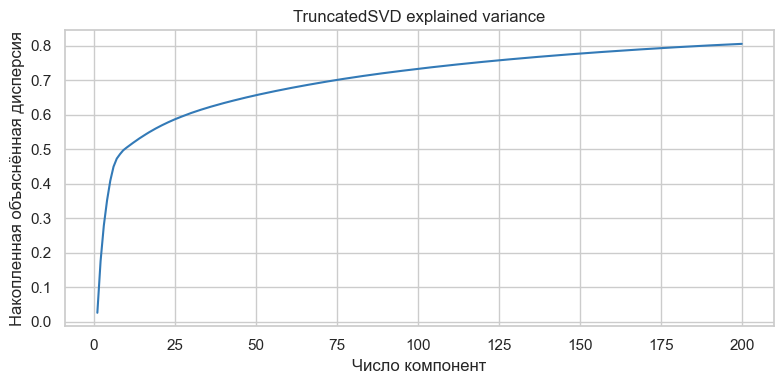

In [14]:
svd_pipe = Pipeline(steps=[
    ("prep", preprocessor),
    ("svd", TruncatedSVD(n_components=200, random_state=SEED)),
    ("model", wrap_log_target(Ridge(alpha=1.0, random_state=SEED))),
])

t0 = time.perf_counter()
svd_pipe.fit(X_train, y_train)
log_experiment(
    name="Ridge + TruncatedSVD(200)",
    pipeline=svd_pipe,
    fit_seconds=time.perf_counter() - t0,
)

# заодно посмотрим explained variance
explained = svd_pipe.named_steps["svd"].explained_variance_ratio_.cumsum()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.arange(1, len(explained) + 1), explained, color="#337ab7")
ax.set_xlabel("Число компонент")
ax.set_ylabel("Накопленная объяснённая дисперсия")
ax.set_title("TruncatedSVD explained variance")
plt.tight_layout()
plt.savefig(REPORT_IMG / "svd_explained_variance.png", dpi=120)
plt.show()

## 11. Сводная таблица экспериментов на val

In [21]:
results_df = (
    pd.DataFrame(experiments)
    .sort_values("val_MAE")
    .reset_index(drop=True)
)
results_df

,model,fit_sec,train_MAE,val_MAE,val_RMSE,val_R2,best_params,notes
0,Ridge (baseline check),1.2,14982.0,24695.0,42987.0,0.577,{},"Ridge на тех же фичах, что и в CP1... Нужен дл..."
1,RandomForest + RandomizedCV,329.3,12694.0,26734.0,48167.0,0.469,"{'max_depth': None, 'max_features': 0.5, 'min_...","5 итераций × 3 фолда, scoring=neg_MAE на log-ш..."
2,Ridge + TruncatedSVD(200),2.4,27801.0,28817.0,50780.0,0.409,{},
3,LinearSVR + GridSearchCV,27.6,4195.0,29019.0,48548.0,0.460,"{'C': 0.1, 'epsilon': 0.0}",


In [22]:
EXPERIMENTS_PATH = REPORT_IMG.parent / "experiments.csv"
results_df.drop(columns=["best_params"]).to_csv(EXPERIMENTS_PATH, index=False)
with open(REPORT_IMG.parent / "experiments_params.json", "w", encoding="utf-8") as f:
    json.dump(experiments, f, ensure_ascii=False, indent=2, default=str)
print(f"saved: {EXPERIMENTS_PATH}")

saved: /Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/report/experiments.csv


## 12. Финальная модель — оценка на test

Берём модель с лучшим `val_MAE`, прогоняем на test и сохраняем. Test трогаем **один раз**,
после того как все решения уже приняты — иначе он перестанет быть честной оценкой обобщающей способности.

### Обоснование выбора
Финальная модель — та, у которой `val_MAE` минимален при разумных затратах. Если разрыв
между топ-2 моделями маленький (< 1–2%), при прочих равных предпочитаем более простую и быструю
(меньше время инференса в проде, проще объяснить интерпретируемость).

In [24]:
name_to_pipeline = {
    "Ridge (baseline check)": ridge_pipe,
    "RandomForest + RandomizedCV": rf_best,
    "LinearSVR + GridSearchCV": svm_best,
    "CatBoost + RandomizedCV": cb_best,
    "Ridge + TruncatedSVD(200)": svd_pipe,
}

best_name = results_df.iloc[0]["model"]
best_pipeline = name_to_pipeline[best_name]
print(f"финальная модель: {best_name}")

test_pred = best_pipeline.predict(X_test)
test_metrics = evaluate(y_test, test_pred)
print("test:", {k: round(v, 3) for k, v in test_metrics.items()})

MODEL_PATH = MODELS_DIR / "final_model.joblib"
joblib.dump(best_pipeline, MODEL_PATH)
print(f"saved: {MODEL_PATH}")

# карточка финальной модели — пригодится для отчёта и деплоя
card = {
    "model_name": best_name,
    "seed": SEED,
    "target": TARGET,
    "target_transform": "log1p / expm1",
    "feature_groups": {
        "num_cols": num_cols,
        "cat_cols": cat_cols,
        "text_col": text_cols,
    },
    "split": {
        "train": int(len(train_df)),
        "val": int(len(val_df)),
        "test": int(len(test_df)),
    },
    "val_metrics": {
        k: round(v, 3) for k, v in evaluate(y_val, best_pipeline.predict(X_val)).items()
    },
    "test_metrics": {k: round(v, 3) for k, v in test_metrics.items()},
}
with open(MODELS_DIR / "final_model.json", "w", encoding="utf-8") as f:
    json.dump(card, f, ensure_ascii=False, indent=2, default=str)
print(json.dumps(card, ensure_ascii=False, indent=2, default=str))

финальная модель: Ridge (baseline check)
test: {'MAE': np.float64(26872.429), 'RMSE': np.float64(66387.536), 'R2': 0.374}
saved: /Users/dianochka_l/Desktop/ML_darinka/Project_HH/hseml-group-project-dianochka-l-1/hseml-group-project-dianochka-l-1/models/final_model.joblib
{
  "model_name": "Ridge (baseline check)",
  "seed": 42,
  "target": "salary_mid_rub",
  "target_transform": "log1p / expm1",
  "feature_groups": {
    "num_cols": [
      "key_skills_count"
    ],
    "cat_cols": [
      "area_id",
      "area_name",
      "employer_name",
      "employer_id",
      "experience",
      "experience_name"
    ],
    "text_col": [
      "name",
      "description"
    ]
  },
  "split": {
    "train": 10877,
    "val": 2331,
    "test": 2331
  },
  "val_metrics": {
    "MAE": 24694.505,
    "RMSE": 42987.115,
    "R2": 0.577
  },
  "test_metrics": {
    "MAE": 26872.429,
    "RMSE": 66387.536,
    "R2": 0.374
  }
}


## 13. Анализ остатков

Смотрим, на каких диапазонах зарплат модель ошибается сильнее. Это пригодится в отчёте для
раздела «Финальная модель + интерпретируемость».

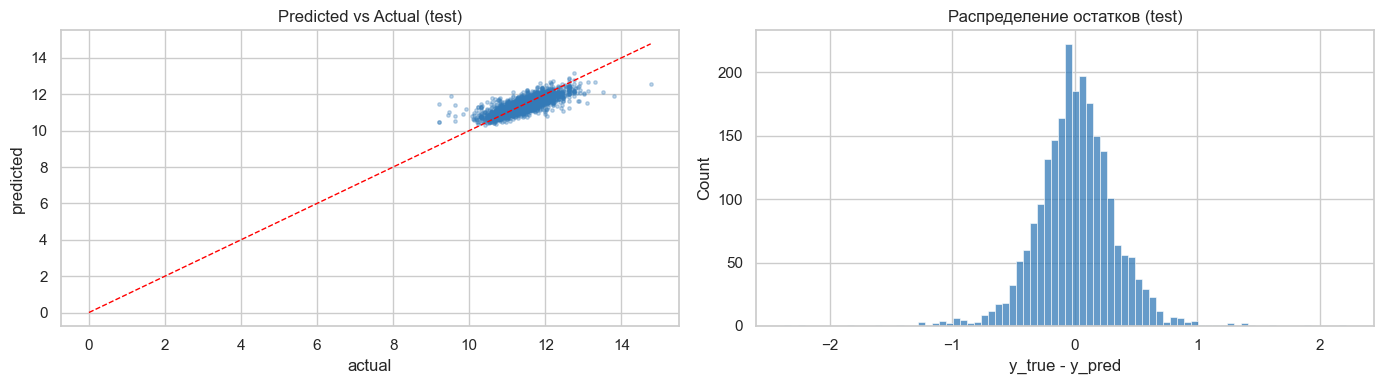

,MAE,MedAE,count
bucket,,,
"(9.209000000000001, 11.002]",0.294091,0.212305,517
"(11.002, 11.268]",0.172284,0.136360,434
"(11.268, 11.513]",0.184977,0.151246,524
"(11.513, 11.844]",0.214513,0.179111,396
"(11.844, 14.771]",0.337884,0.265880,460


In [25]:
residuals = y_test - np.clip(test_pred, 0, None)
abs_residuals = np.abs(residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(y_test, test_pred, s=6, alpha=0.3, color="#337ab7")
lim = max(y_test.max(), test_pred.max())
axes[0].plot([0, lim], [0, lim], color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("actual")
axes[0].set_ylabel("predicted")
axes[0].set_title("Predicted vs Actual (test)")

sns.histplot(residuals, bins=80, ax=axes[1], color="#337ab7")
axes[1].set_title("Распределение остатков (test)")
axes[1].set_xlabel("y_true - y_pred")
plt.tight_layout()
plt.savefig(REPORT_IMG / "residuals.png", dpi=120)
plt.show()

# MAE по бакетам зарплаты — где больше всего «промахиваемся»
bucket_df = pd.DataFrame({"y": y_test, "abs_err": abs_residuals})
bucket_df["bucket"] = pd.qcut(bucket_df["y"], q=5, duplicates="drop")
bucket_stats = (
    bucket_df.groupby("bucket", observed=True)["abs_err"]
    .agg(["mean", "median", "count"])
    .rename(columns={"mean": "MAE", "median": "MedAE"})
)
bucket_stats

## 14. Выводы
